# Transformaciones Lineales en $\mathbb{R}^2$

**Proyecto 0.1 — Álgebra Lineal Visual con NumPy**  
*Portafolio: De Matemático a Data Scientist*

---

## Objetivo

Visualizar cómo las transformaciones lineales $T: \mathbb{R}^2 \to \mathbb{R}^2$ actúan
sobre vectores y regiones del plano. Cada transformación aparece en tres niveles:

1. **Ecuación** — la definición formal en LaTeX
2. **Implementación** — la traducción a NumPy
3. **Gráfico** — la interpretación geométrica en Matplotlib

> *"No estoy aprendiendo a pensar. Estoy aprendiendo a expresar lo que ya pienso en un nuevo idioma."*

---
## Fundamento Matemático

### Definición

Una función $T: \mathbb{R}^n \to \mathbb{R}^m$ es una **transformación lineal** si y solo si:

$$T(\alpha \mathbf{u} + \beta \mathbf{v}) = \alpha\, T(\mathbf{u}) + \beta\, T(\mathbf{v}) \quad \forall\, \mathbf{u}, \mathbf{v} \in \mathbb{R}^n,\; \forall\, \alpha, \beta \in \mathbb{R}$$

Equivalentemente, $T$ preserva la suma de vectores y la multiplicación por escalar.

### Teorema de representación matricial

Toda transformación lineal $T: \mathbb{R}^n \to \mathbb{R}^m$ se puede expresar como multiplicación por una matriz $A \in \mathbb{R}^{m \times n}$:

$$T(\mathbf{x}) = A\mathbf{x}$$

donde las columnas de $A$ son las imágenes de los vectores canónicos: $A = [T(\mathbf{e}_1) \mid T(\mathbf{e}_2) \mid \cdots \mid T(\mathbf{e}_n)]$.

**Justificación:** Todo $\mathbf{x} \in \mathbb{R}^n$ se escribe como combinación lineal de la base canónica: $\mathbf{x} = \sum_{i=1}^n x_i \mathbf{e}_i$. Aplicando $T$ y usando linealidad:

$$T(\mathbf{x}) = T\!\left(\sum_{i=1}^n x_i \mathbf{e}_i\right) = \sum_{i=1}^n x_i\, T(\mathbf{e}_i) = \underbrace{[\,T(\mathbf{e}_1) \mid \cdots \mid T(\mathbf{e}_n)\,]}_{= A}\,\mathbf{x} = A\mathbf{x}$$

La representación es **única**: si $B\mathbf{x} = T(\mathbf{x})$ para todo $\mathbf{x}$, evaluando en cada $\mathbf{e}_i$ se obtiene $B\mathbf{e}_i = T(\mathbf{e}_i)$, y por tanto $B$ tiene las mismas columnas que $A$, es decir, $B = A$.

### Transformaciones que estudiaremos en este notebook

| Transformación | Matriz $A$ | Efecto geométrico |
|---|---|---|
| Rotación por $\theta$ | $\begin{pmatrix} \cos\theta & -\sin\theta \\ \sin\theta & \cos\theta \end{pmatrix}$ | Gira vectores sin cambiar su norma |
| Reflexión respecto a eje $x$ | $\begin{pmatrix} 1 & 0 \\ 0 & -1 \end{pmatrix}$ | Espejo horizontal |
| Reflexión respecto a eje $y$ | $\begin{pmatrix} -1 & 0 \\ 0 & 1 \end{pmatrix}$ | Espejo vertical |
| Reflexión respecto a $y = x$ | $\begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix}$ | Intercambia coordenadas |
| Escalado por $(s_x, s_y)$ | $\begin{pmatrix} s_x & 0 \\ 0 & s_y \end{pmatrix}$ | Estira/comprime en cada eje |
| Proyección sobre eje $x$ | $\begin{pmatrix} 1 & 0 \\ 0 & 0 \end{pmatrix}$ | Colapsa la componente $y$ |
| Cizallamiento (shear) | $\begin{pmatrix} 1 & k \\ 0 & 1 \end{pmatrix}$ | Inclina en dirección horizontal |

---
## Configuración inicial

In [1]:
%matplotlib inline

import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from src.visualization import dibujar_vector, configurar_ejes, slugify

# Gráficos con fondo limpio, tamaño legible
plt.rcParams.update({
    'figure.figsize': (8, 8),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.axisbelow': True,
    'font.size': 12
})

print(f"NumPy versión: {np.__version__}")
print("Configuración cargada correctamente ✓")

NumPy versión: 2.4.2
Configuración cargada correctamente ✓


---
## Funciones auxiliares de visualización

Estas funciones se reutilizarán en todo el notebook. La idea es separarlas
de la lógica matemática para mantener el código limpio.

In [2]:
def dibujar_transformacion(A, titulo, vectores_base=None):
    """
    Visualiza el efecto de una transformación lineal A sobre:
    - Los vectores canónicos e1, e2
    - Un conjunto de vectores adicionales (opcional)
    - Un cuadrado unitario (para ver la deformación de regiones)

    Parámetros:
        A             : np.array de forma (2, 2) — la matriz de la transformación
        titulo        : string — título del gráfico
        vectores_base : list de np.array — vectores adicionales a transformar
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # === Panel izquierdo: ANTES de la transformación ===
    e1 = np.array([1, 0])  # Vector canónico e1
    e2 = np.array([0, 1])  # Vector canónico e2

    dibujar_vector(ax1, e1, color='#2196F3', label='$\mathbf{e}_1$')
    dibujar_vector(ax1, e2, color='#F44336', label='$\mathbf{e}_2$')

    # Cuadrado unitario original
    cuadrado = np.array([[0,0], [1,0], [1,1], [0,1], [0,0]]).T
    ax1.fill(cuadrado[0], cuadrado[1], alpha=0.15, color='gray')
    ax1.plot(cuadrado[0], cuadrado[1], 'k--', alpha=0.4, linewidth=1)

    # Vectores adicionales
    colores_extra = ['#9C27B0', '#FF9800', '#009688']
    if vectores_base:
        for i, v in enumerate(vectores_base):
            c = colores_extra[i % len(colores_extra)]
            dibujar_vector(ax1, v, color=c, label=f'$\mathbf{{v}}_{i+1}$')

    configurar_ejes(ax1, 'Antes: dominio')
    ax1.legend(loc='upper left', fontsize=10)

    # === Panel derecho: DESPUÉS de la transformación ===
    Ae1 = A @ e1  # Imagen de e1
    Ae2 = A @ e2  # Imagen de e2

    dibujar_vector(ax2, Ae1, color='#2196F3', label=f'$A\mathbf{{e}}_1 = ({Ae1[0]:.2f}, {Ae1[1]:.2f})$')
    dibujar_vector(ax2, Ae2, color='#F44336', label=f'$A\mathbf{{e}}_2 = ({Ae2[0]:.2f}, {Ae2[1]:.2f})$')

    # Cuadrado transformado (paralelogramo)
    cuadrado_transformado = A @ cuadrado
    ax2.fill(cuadrado_transformado[0], cuadrado_transformado[1], alpha=0.15, color='purple')
    ax2.plot(cuadrado_transformado[0], cuadrado_transformado[1], 'k--', alpha=0.4, linewidth=1)

    # Vectores adicionales transformados
    if vectores_base:
        for i, v in enumerate(vectores_base):
            Av = A @ v
            c = colores_extra[i % len(colores_extra)]
            dibujar_vector(ax2, Av, color=c, label=f'$A\mathbf{{v}}_{i+1} = ({Av[0]:.2f}, {Av[1]:.2f})$')

    # Mostrar el determinante — mide cómo cambia el área
    det = np.linalg.det(A)
    configurar_ejes(ax2, f'Después: imagen — det(A) = {det:.3f}')
    ax2.legend(loc='upper left', fontsize=9)

    fig.suptitle(titulo, fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f'../reports/figures/{slugify(titulo)}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    # Información numérica
    print(f"Matriz A:\n{A}")
    print(f"\nDeterminante: {det:.6f}")
    print(f"  → {'Preserva' if det > 0 else 'Invierte'} la orientación")
    print(f"  → El área se {'multiplica' if abs(det) != 1 else 'preserva'} por |det| = {abs(det):.6f}")


print("Funciones auxiliares cargadas ✓")

Funciones auxiliares cargadas ✓


---
## 1. Rotación

### Definición

La rotación por un ángulo $\theta$ (en sentido antihorario) alrededor del origen está dada por:

$$R_\theta = \begin{pmatrix} \cos\theta & -\sin\theta \\ \sin\theta & \cos\theta \end{pmatrix}$$

**Propiedades importantes:**
- $\det(R_\theta) = \cos^2\theta + \sin^2\theta = 1$,  preserva áreas y orientación
- $R_\theta^{-1} = R_{-\theta} = R_\theta^T$,  es una **matriz ortogonal**
- $R_\alpha \cdot R_\beta = R_{\alpha + \beta}$,  las rotaciones forman un **grupo** bajo composición
- $\|R_\theta \mathbf{v}\| = \|\mathbf{v}\|$,  preserva normas (es una **isometría**)

C:\Users\Eduardo Araque\AppData\Local\Temp\ipykernel_6972\1082664087.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(loc='upper left', fontsize=10)


C:\Users\Eduardo Araque\AppData\Local\Temp\ipykernel_6972\1082664087.py:59: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(loc='upper left', fontsize=9)


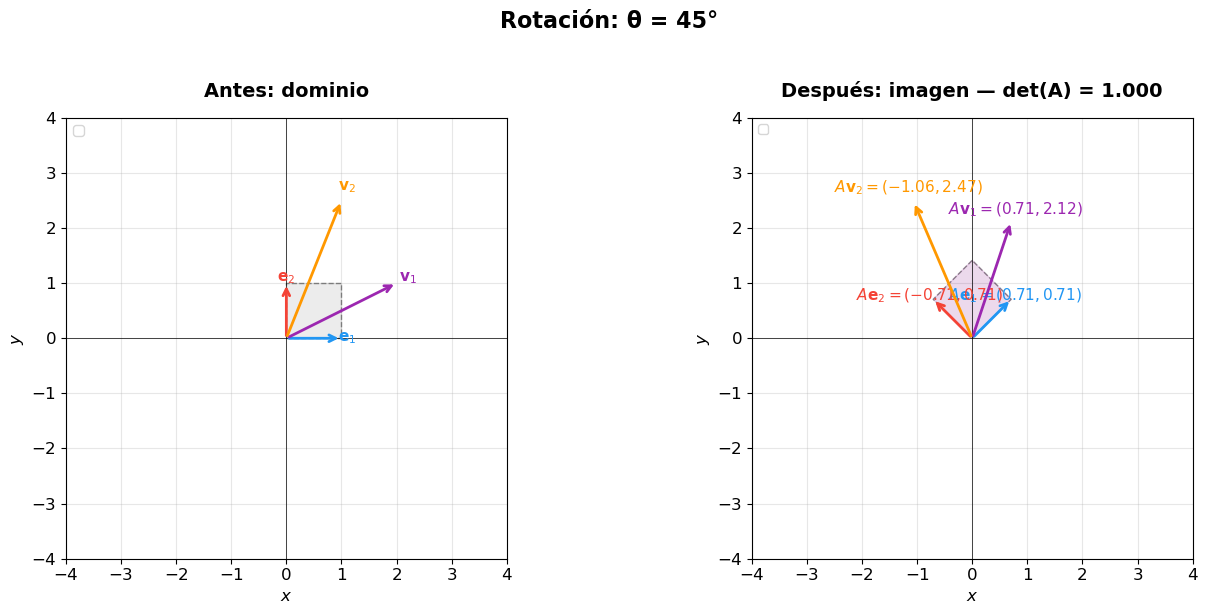

Matriz A:
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]

Determinante: 1.000000
  → Preserva la orientación
  → El área se preserva por |det| = 1.000000


In [3]:
def matriz_rotacion(theta_grados):
    """
    Construye la matriz de rotación para un ángulo dado en grados.
    
    Parámetros:
        theta_grados : float — ángulo de rotación en grados
    
    Retorna:
        np.array de forma (2, 2) — la matriz de rotación R_θ
    """
    theta = np.radians(theta_grados)  # NumPy trabaja en radianes
    return np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta),  np.cos(theta)]
    ])


# Rotación de 45°
R45 = matriz_rotacion(45)

# Vectores de prueba para ver el efecto
v1 = np.array([2, 1])
v2 = np.array([1, 2.5])

dibujar_transformacion(R45, 'Rotación: θ = 45°', vectores_base=[v1, v2])

In [4]:
# Verificación numérica: la rotación preserva normas
v = np.array([3, 4])  # ||v|| = 5
Rv = R45 @ v

print(f"v  = {v}")
print(f"Rv = {Rv}")
print(f"||v||  = {np.linalg.norm(v):.10f}")
print(f"||Rv|| = {np.linalg.norm(Rv):.10f}")
print(f"\n¿Normas iguales? Diferencia = {abs(np.linalg.norm(v) - np.linalg.norm(Rv)):.2e}")

# Verificación: R^T R = I (ortogonalidad)
producto = R45.T @ R45
print(f"\nR^T · R =\n{producto}")
print(f"¿Es identidad? Error máximo = {np.max(np.abs(producto - np.eye(2))):.2e}")

v  = [3 4]
Rv = [-0.70710678  4.94974747]


||v||  = 5.0000000000
||Rv|| = 5.0000000000

¿Normas iguales? Diferencia = 8.88e-16



R^T · R =
[[1. 0.]
 [0. 1.]]
¿Es identidad? Error máximo = 2.22e-16


### Composición de rotaciones

Si $R_\alpha$ y $R_\beta$ son rotaciones, entonces $R_\alpha R_\beta = R_{\alpha+\beta}$.

Esto es una consecuencia directa de las identidades trigonométricas de suma de ángulos:

$$\cos(\alpha+\beta) = \cos\alpha\cos\beta - \sin\alpha\sin\beta$$
$$\sin(\alpha+\beta) = \sin\alpha\cos\beta + \cos\alpha\sin\beta$$

In [5]:
# Verificación: R(30°) · R(60°) = R(90°)
R30 = matriz_rotacion(30)
R60 = matriz_rotacion(60)
R90 = matriz_rotacion(90)

# Composición
R30_R60 = R30 @ R60

print("R(30°) · R(60°) =")
print(R30_R60)
print(f"\nR(90°) =")
print(R90)
print(f"\n¿Son iguales? Error máximo = {np.max(np.abs(R30_R60 - R90)):.2e}")

R(30°) · R(60°) =
[[ 2.22044605e-16 -1.00000000e+00]
 [ 1.00000000e+00  2.22044605e-16]]

R(90°) =
[[ 6.123234e-17 -1.000000e+00]
 [ 1.000000e+00  6.123234e-17]]

¿Son iguales? Error máximo = 1.61e-16


### Visualización: efecto continuo de la rotación

Veamos cómo un vector se mueve suavemente al variar $\theta$ de $0°$ a $360°$.

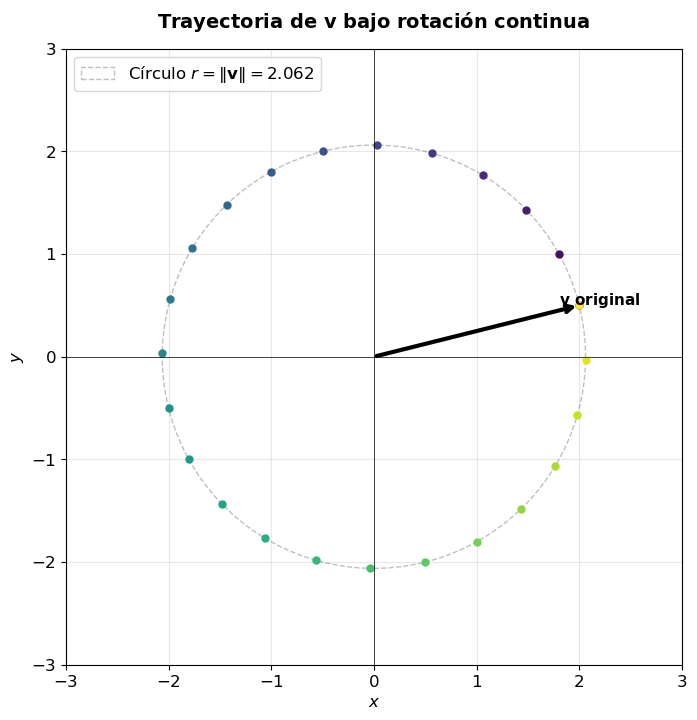

||v|| = 2.0615528128 — todos los puntos están sobre este círculo


In [6]:
fig, ax = plt.subplots(figsize=(8, 8))

v_original = np.array([2, 0.5])
angulos = np.arange(0, 361, 15)  # De 0° a 360° en pasos de 15°

# Dibujar el vector original con énfasis
dibujar_vector(ax, v_original, color='black', label='$\mathbf{v}$ original', lw=3)

# Dibujar las rotaciones con un gradiente de color
colores = plt.cm.viridis(np.linspace(0, 1, len(angulos)))

for i, theta in enumerate(angulos):
    R = matriz_rotacion(theta)
    v_rotado = R @ v_original
    # Solo la punta del vector, como punto
    ax.plot(v_rotado[0], v_rotado[1], 'o', color=colores[i], markersize=5)

# La trayectoria es un círculo de radio ||v||
norma = np.linalg.norm(v_original)
circulo = plt.Circle((0, 0), norma, fill=False, color='gray',
                      linestyle='--', alpha=0.5, label=f'Círculo $r = \|\mathbf{{v}}\| = {norma:.3f}$')
ax.add_patch(circulo)

configurar_ejes(ax, 'Trayectoria de $\mathbf{v}$ bajo rotación continua', lim=3)
ax.legend(loc='upper left')

plt.savefig('../reports/figures/rotacion_continua.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"||v|| = {norma:.10f} — todos los puntos están sobre este círculo")

---
## 2. Reflexiones

### Definición

Una **reflexión** es una transformación lineal que "espeja" vectores respecto a un subespacio
(en $\mathbb{R}^2$, respecto a una recta que pasa por el origen).

**Reflexión respecto a una recta que forma ángulo $\phi$ con el eje $x$:**

$$S_\phi = \begin{pmatrix} \cos 2\phi & \sin 2\phi \\ \sin 2\phi & -\cos 2\phi \end{pmatrix}$$

Casos particulares:
- $\phi = 0$ (eje $x$): $S = \begin{pmatrix} 1 & 0 \\ 0 & -1 \end{pmatrix}$
- $\phi = \pi/2$ (eje $y$): $S = \begin{pmatrix} -1 & 0 \\ 0 & 1 \end{pmatrix}$
- $\phi = \pi/4$ (recta $y=x$): $S = \begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix}$

**Propiedades:**
- $\det(S_\phi) = -1$,  invierte la orientación (convierte sentido horario en antihorario)
- $S_\phi^2 = I$,  aplicar la reflexión dos veces devuelve al vector original (es una **involución**)
- $S_\phi$ es ortogonal: $S_\phi^T S_\phi = I$,  preserva normas y ángulos

**Derivación de la fórmula general:** Reflexionar respecto a una recta de ángulo $\phi$ se descompone en tres pasos:

1. Rotar $-\phi$ para alinear esa recta con el eje $x$ (donde la reflexión es trivial)
2. Reflejar respecto al eje $x$: negar la componente $y$, es decir, aplicar $\operatorname{diag}(1, -1)$
3. Rotar $+\phi$ para regresar a la orientación original

En términos matriciales:

$$S_\phi = R_\phi \begin{pmatrix} 1 & 0 \\ 0 & -1 \end{pmatrix} R_{-\phi}$$

Expandiendo con $\cos(-\phi) = \cos\phi$, $\sin(-\phi) = -\sin\phi$ y las identidades de ángulo doble $(\cos 2\phi = \cos^2\phi - \sin^2\phi,\; \sin 2\phi = 2\sin\phi\cos\phi)$, se obtiene directamente la fórmula de $S_\phi$ mostrada arriba.

C:\Users\Eduardo Araque\AppData\Local\Temp\ipykernel_6972\1082664087.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(loc='upper left', fontsize=10)
C:\Users\Eduardo Araque\AppData\Local\Temp\ipykernel_6972\1082664087.py:59: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(loc='upper left', fontsize=9)


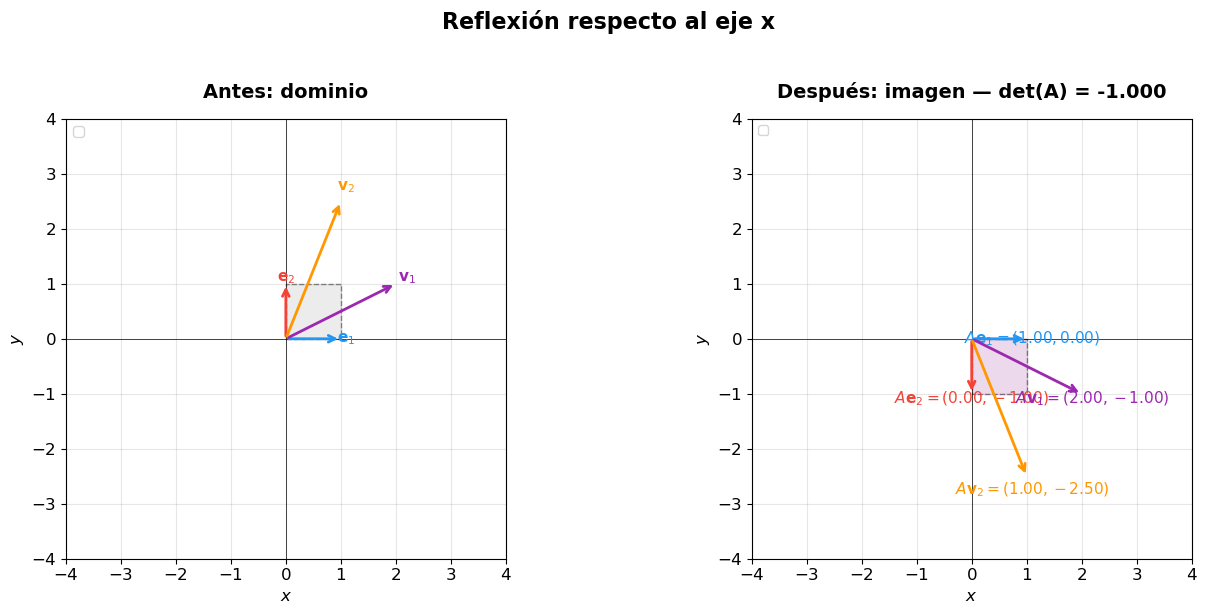

Matriz A:
[[ 1  0]
 [ 0 -1]]

Determinante: -1.000000
  → Invierte la orientación
  → El área se preserva por |det| = 1.000000


In [7]:
# Reflexión respecto al eje x
S_eje_x = np.array([
    [1,  0],
    [0, -1]
])

dibujar_transformacion(S_eje_x, 'Reflexión respecto al eje x', vectores_base=[v1, v2])

C:\Users\Eduardo Araque\AppData\Local\Temp\ipykernel_6972\1082664087.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(loc='upper left', fontsize=10)
C:\Users\Eduardo Araque\AppData\Local\Temp\ipykernel_6972\1082664087.py:59: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(loc='upper left', fontsize=9)


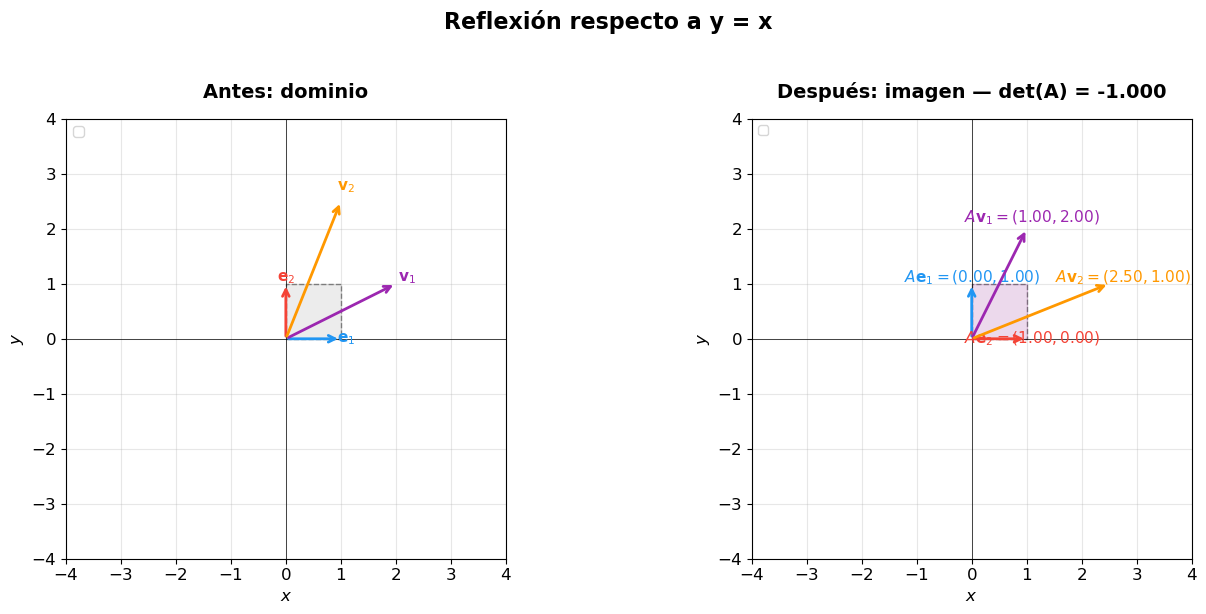

Matriz A:
[[0 1]
 [1 0]]

Determinante: -1.000000
  → Invierte la orientación
  → El área se preserva por |det| = 1.000000


In [8]:
# Reflexión respecto a la recta y = x
S_yx = np.array([
    [0, 1],
    [1, 0]
])

dibujar_transformacion(S_yx, 'Reflexión respecto a y = x', vectores_base=[v1, v2])

In [9]:
# Verificación: S² = I (involución)
S2 = S_eje_x @ S_eje_x
print(f"S_x · S_x =\n{S2}")
print(f"\n¿Es la identidad? {np.allclose(S2, np.eye(2))}")

# Verificación: det(S) = -1
print(f"\ndet(S_eje_x)  = {np.linalg.det(S_eje_x):.1f}")
print(f"det(S_y=x)    = {np.linalg.det(S_yx):.1f}")

S_x · S_x =
[[1 0]
 [0 1]]

¿Es la identidad? True

det(S_eje_x)  = -1.0
det(S_y=x)    = -1.0


### Reflexión respecto a una recta arbitraria

La fórmula general para la reflexión respecto a la recta que forma ángulo $\phi$ con el eje $x$:

C:\Users\Eduardo Araque\AppData\Local\Temp\ipykernel_6972\1082664087.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(loc='upper left', fontsize=10)
C:\Users\Eduardo Araque\AppData\Local\Temp\ipykernel_6972\1082664087.py:59: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(loc='upper left', fontsize=9)


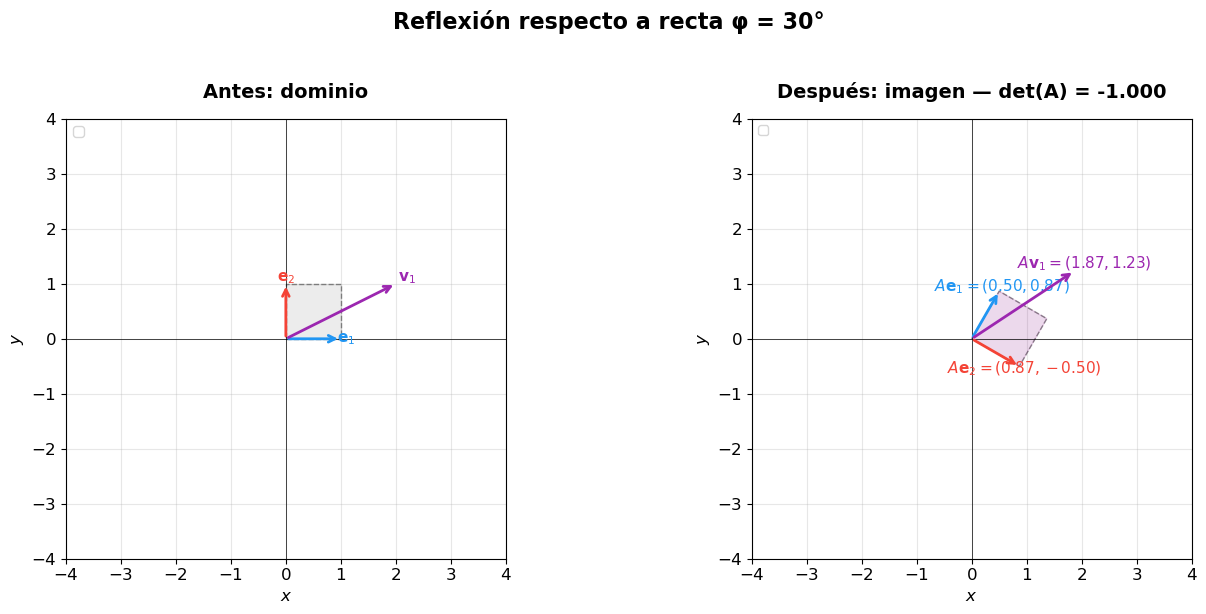

Matriz A:
[[ 0.5        0.8660254]
 [ 0.8660254 -0.5      ]]

Determinante: -1.000000
  → Invierte la orientación
  → El área se preserva por |det| = 1.000000


In [10]:
def matriz_reflexion(phi_grados):
    """
    Construye la matriz de reflexión respecto a una recta
    que forma ángulo phi con el eje x.
    
    Parámetros:
        phi_grados : float — ángulo de la recta de reflexión en grados
    
    Retorna:
        np.array de forma (2, 2) — la matriz de reflexión S_φ
    """
    phi = np.radians(phi_grados)
    return np.array([
        [ np.cos(2*phi), np.sin(2*phi)],
        [ np.sin(2*phi), -np.cos(2*phi)]
    ])


# Reflexión respecto a la recta con ángulo de 30°
S30 = matriz_reflexion(30)
dibujar_transformacion(S30, 'Reflexión respecto a recta φ = 30°', vectores_base=[v1])

---
## 3. Escalado (Scaling)

### Definición

El escalado por factores $(s_x, s_y)$ está dado por la matriz diagonal:

$$D = \begin{pmatrix} s_x & 0 \\ 0 & s_y \end{pmatrix}$$

**Propiedades:**
- $\det(D) = s_x \cdot s_y$,  el área se multiplica por este "factor de escala"
- Los **ejes coordenados** son los vectores propios (con valores propios $s_x$ y $s_y$)
- Si $s_x = s_y = k$: homotecia — escalado uniforme, $D = kI$
- Si $s_x \neq s_y$: la transformación deforma el espacio de forma anisotrópica (estirando o comprimiendo más en un eje (ej. vertical) que en otro (horizontal))

C:\Users\Eduardo Araque\AppData\Local\Temp\ipykernel_6972\1082664087.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(loc='upper left', fontsize=10)
C:\Users\Eduardo Araque\AppData\Local\Temp\ipykernel_6972\1082664087.py:59: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(loc='upper left', fontsize=9)


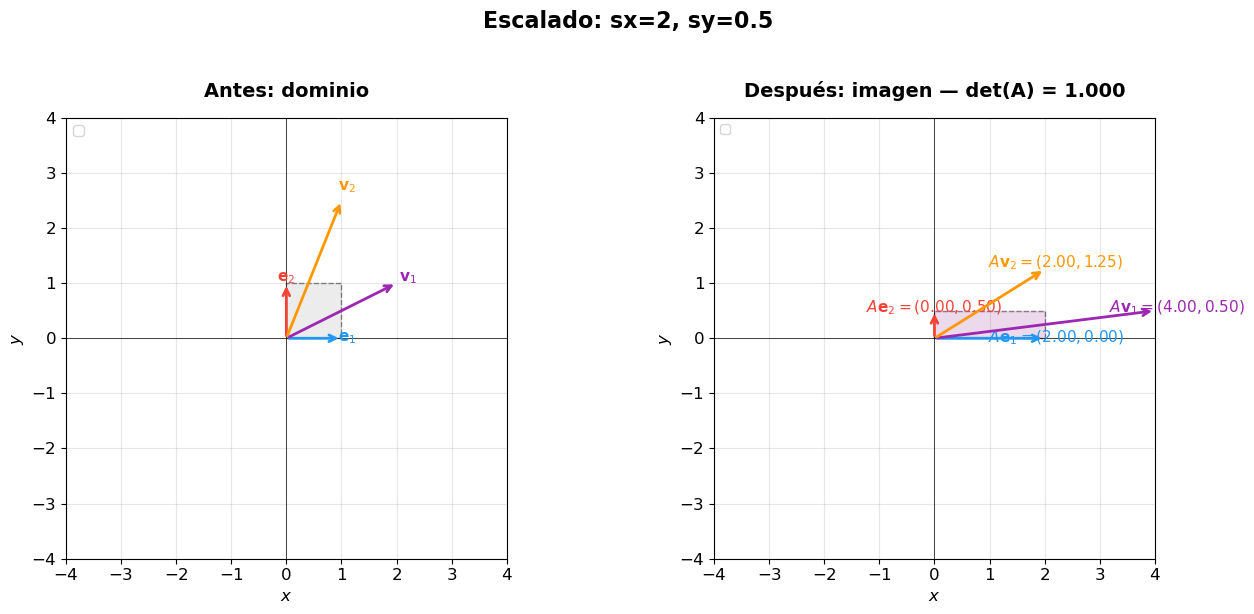

Matriz A:
[[2.  0. ]
 [0.  0.5]]

Determinante: 1.000000
  → Preserva la orientación
  → El área se preserva por |det| = 1.000000


In [11]:
# Escalado no uniforme: estirar en x, comprimir en y
D_aniso = np.array([
    [2.0, 0.0],
    [0.0, 0.5]
])

dibujar_transformacion(D_aniso, 'Escalado: sx=2, sy=0.5', vectores_base=[v1, v2])

C:\Users\Eduardo Araque\AppData\Local\Temp\ipykernel_6972\1082664087.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(loc='upper left', fontsize=10)
C:\Users\Eduardo Araque\AppData\Local\Temp\ipykernel_6972\1082664087.py:59: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(loc='upper left', fontsize=9)


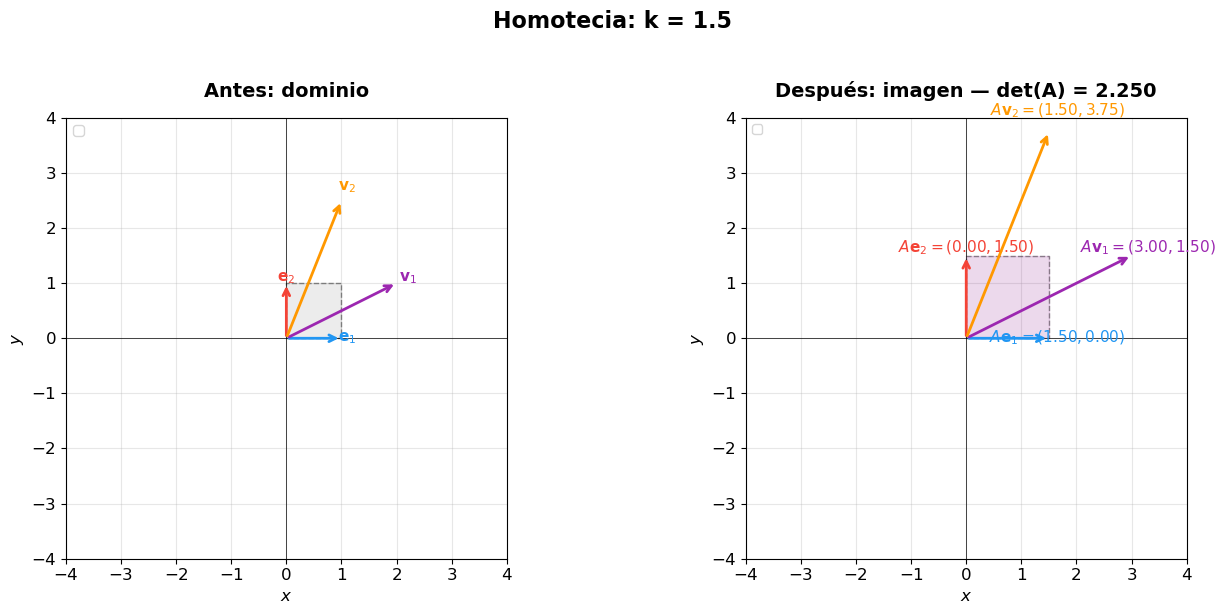

Matriz A:
[[1.5 0. ]
 [0.  1.5]]

Determinante: 2.250000
  → Preserva la orientación
  → El área se multiplica por |det| = 2.250000


In [12]:
# Escalado uniforme (homotecia)
k = 1.5
D_homo = k * np.eye(2)

dibujar_transformacion(D_homo, f'Homotecia: k = {k}', vectores_base=[v1, v2])

---
## 4. Proyección ortogonal

### Definición

La **proyección ortogonal** sobre un subespacio unidimensional (caso particular) generado por
un vector unitario $\hat{\mathbf{u}}$ está dada por:

$$P = \hat{\mathbf{u}} \hat{\mathbf{u}}^T$$

Para $\hat{\mathbf{u}} = (\cos\phi, \sin\phi)^T$ (dirección que forma ángulo $\phi$ con eje $x$):

$$P_\phi = \begin{pmatrix} \cos^2\phi & \cos\phi\sin\phi \\ \cos\phi\sin\phi & \sin^2\phi \end{pmatrix}$$

**¿Por qué $P = \hat{\mathbf{u}}\hat{\mathbf{u}}^T$?** La proyección de $\mathbf{x}$ sobre $\hat{\mathbf{u}}$ es el vector en la dirección $\hat{\mathbf{u}}$ cuya longitud es la componente escalar de $\mathbf{x}$ en esa dirección:

$$P\mathbf{x} = \underbrace{(\hat{\mathbf{u}}^T \mathbf{x})}_{\text{escalar}} \hat{\mathbf{u}} = \hat{\mathbf{u}}(\hat{\mathbf{u}}^T \mathbf{x}) = (\hat{\mathbf{u}}\hat{\mathbf{u}}^T)\mathbf{x}$$

El reordenamiento del segundo al tercer paso es válido porque $(\hat{\mathbf{u}}^T \mathbf{x})$ es un escalar: $\hat{\mathbf{u}} \cdot c = c \cdot \hat{\mathbf{u}}$ para cualquier $c \in \mathbb{R}$. La expresión $\hat{\mathbf{u}}\hat{\mathbf{u}}^T$ es el **producto exterior** de $\hat{\mathbf{u}}$ consigo mismo, una matriz de rango 1 que actúa exactamente como $P$.

**Propiedades:**
- $P^2 = P$,  es **idempotente** (proyectar dos veces = proyectar una vez)
- $P^T = P$,  es simétrica
- $\det(P) = 0$,  colapsa una dimensión (no es invertible)
- Valores propios: $\lambda_1 = 1$ (dirección de la proyección) y $\lambda_2 = 0$ (dirección ortogonal)

C:\Users\Eduardo Araque\AppData\Local\Temp\ipykernel_6972\1082664087.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(loc='upper left', fontsize=10)
C:\Users\Eduardo Araque\AppData\Local\Temp\ipykernel_6972\1082664087.py:59: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(loc='upper left', fontsize=9)


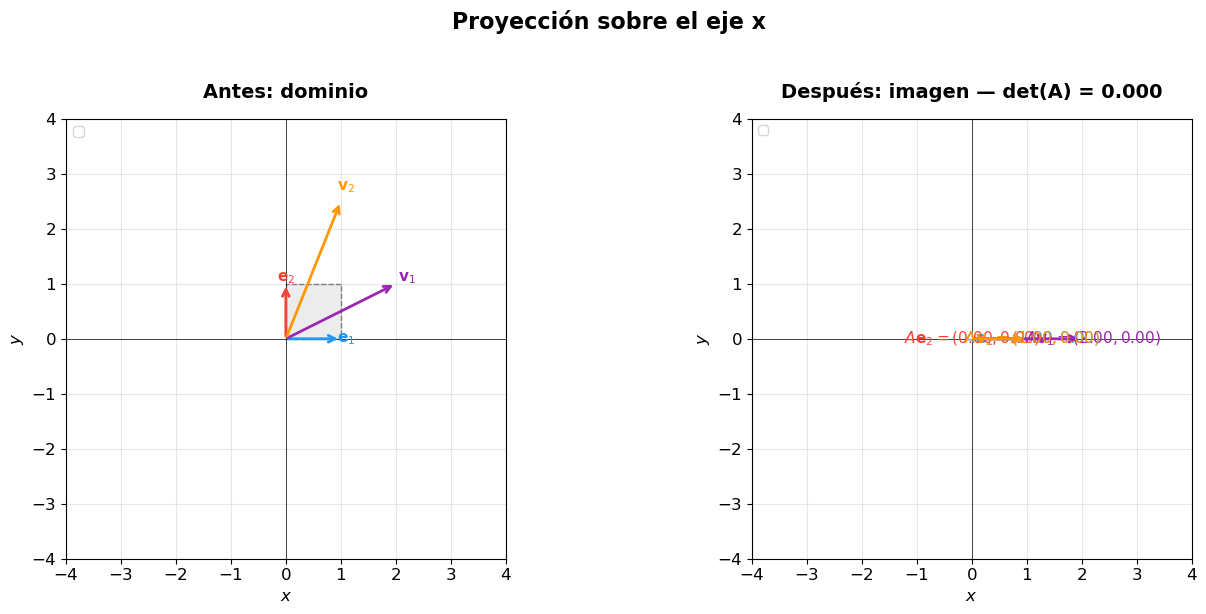

Matriz A:
[[1 0]
 [0 0]]

Determinante: 0.000000
  → Invierte la orientación
  → El área se multiplica por |det| = 0.000000


In [13]:
# Proyección sobre el eje x
P_x = np.array([
    [1, 0],
    [0, 0]
])

dibujar_transformacion(P_x, 'Proyección sobre el eje x', vectores_base=[v1, v2])

C:\Users\Eduardo Araque\AppData\Local\Temp\ipykernel_6972\1082664087.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(loc='upper left', fontsize=10)
C:\Users\Eduardo Araque\AppData\Local\Temp\ipykernel_6972\1082664087.py:59: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(loc='upper left', fontsize=9)


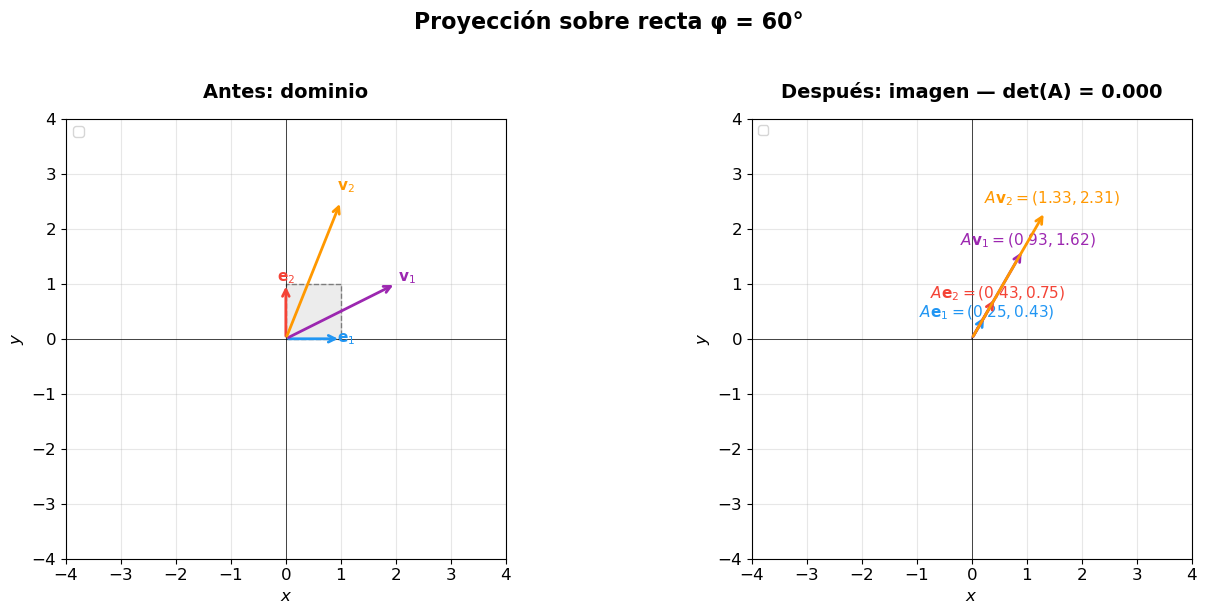

Matriz A:
[[0.25      0.4330127]
 [0.4330127 0.75     ]]

Determinante: 0.000000
  → Invierte la orientación
  → El área se multiplica por |det| = 0.000000


In [14]:
def matriz_proyeccion(phi_grados):
    """
    Construye la matriz de proyección ortogonal sobre la recta
    que forma ángulo phi con el eje x.
    
    Parámetros:
        phi_grados : float — ángulo de la recta sobre la cual proyectar
    
    Retorna:
        np.array de forma (2, 2) — la matriz de proyección P_φ
    """
    phi = np.radians(phi_grados)
    u = np.array([np.cos(phi), np.sin(phi)])  # Vector unitario en dirección φ
    return np.outer(u, u)  # P = u · u^T — producto exterior


# Proyección sobre la recta a 60°
P60 = matriz_proyeccion(60)
dibujar_transformacion(P60, 'Proyección sobre recta φ = 60°', vectores_base=[v1, v2])

In [15]:
# Verificación: P² = P (idempotencia)
P60_2 = P60 @ P60
print(f"P =\n{P60}")
print(f"\nP² =\n{P60_2}")
print(f"\n¿P² = P? {np.allclose(P60, P60_2)}")
print(f"det(P) = {np.linalg.det(P60):.6f}  (debe ser 0 — colapsa una dimensión)")

P =
[[0.25      0.4330127]
 [0.4330127 0.75     ]]

P² =
[[0.25      0.4330127]
 [0.4330127 0.75     ]]

¿P² = P? True
det(P) = 0.000000  (debe ser 0 — colapsa una dimensión)


---
## 5. Cizallamiento (Shear)

### Definición

El cizallamiento horizontal por factor $k$ está dado por:

$$H_k = \begin{pmatrix} 1 & k \\ 0 & 1 \end{pmatrix}$$

Efecto: desplaza la componente $x$ de cada vector proporcionalmente a su componente $y$.
El vector $(x, y)$ se mapea a $(x + ky, y)$.

**Propiedades:**
- $\det(H_k) = 1$,  preserva áreas — consecuencia directa de que $H_k$ es **triangular** con 1s en la diagonal: el determinante de una matriz triangular es el producto de sus entradas diagonales, aquí $1 \cdot 1 = 1$ independientemente de $k$
- No es una isometría: cambia ángulos y normas
- $H_k^{-1} = H_{-k}$,  el cizallamiento inverso deshace el original

C:\Users\Eduardo Araque\AppData\Local\Temp\ipykernel_6972\1082664087.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(loc='upper left', fontsize=10)
C:\Users\Eduardo Araque\AppData\Local\Temp\ipykernel_6972\1082664087.py:59: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(loc='upper left', fontsize=9)


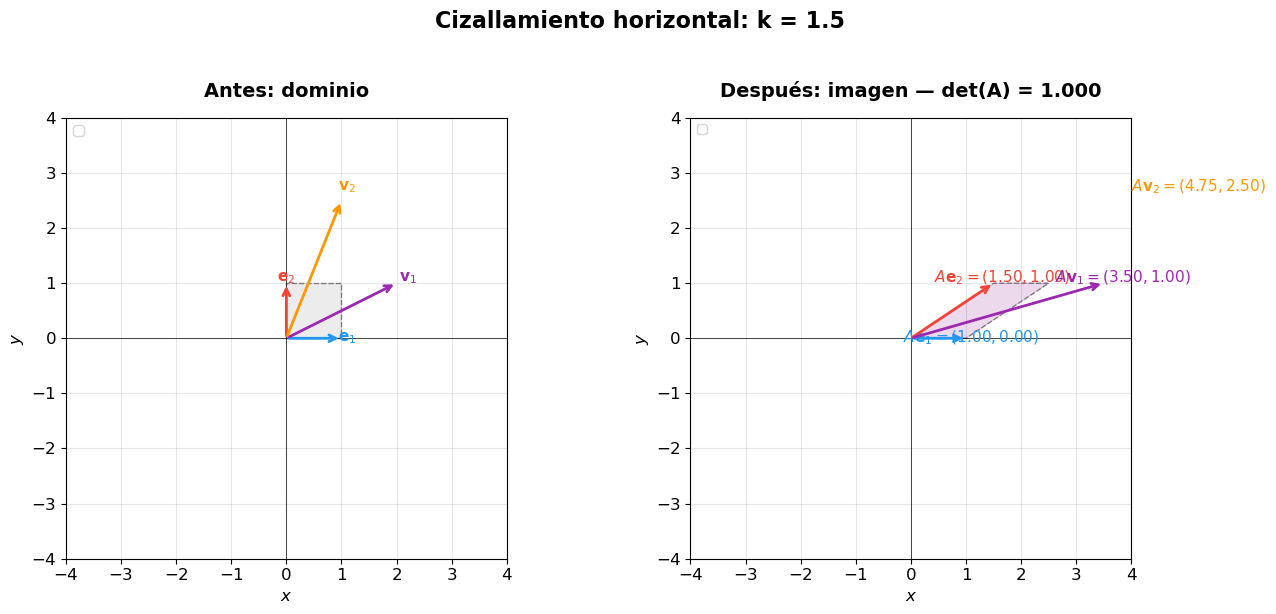

Matriz A:
[[1.  1.5]
 [0.  1. ]]

Determinante: 1.000000
  → Preserva la orientación
  → El área se preserva por |det| = 1.000000


In [16]:
# Cizallamiento horizontal con k = 1.5
k_shear = 1.5
H = np.array([
    [1, k_shear],
    [0, 1]
])

dibujar_transformacion(H, f'Cizallamiento horizontal: k = {k_shear}', vectores_base=[v1, v2])

In [17]:
# Verificación: H_k · H_{-k} = I
H_inv = np.array([
    [1, -k_shear],
    [0,  1]
])

print(f"H · H⁻¹ =\n{H @ H_inv}")
print(f"\n¿Es identidad? {np.allclose(H @ H_inv, np.eye(2))}")

H · H⁻¹ =
[[1. 0.]
 [0. 1.]]

¿Es identidad? True


---
## 6. Composición de transformaciones

### Proposición

Si $T_1(\mathbf{x}) = A_1 \mathbf{x}$ y $T_2(\mathbf{x}) = A_2 \mathbf{x}$, entonces:

$$T_2 \circ T_1(\mathbf{x}) = A_2(A_1 \mathbf{x}) = (A_2 A_1)\mathbf{x}$$

**Nota crucial:** La composición $T_2 \circ T_1$ se lee "primero $T_1$, luego $T_2$",
pero en la multiplicación matricial el orden es $A_2 A_1$ (derecha a izquierda).

**En general, $A_2 A_1 \neq A_1 A_2$**,  la composición de transformaciones lineales
**no es conmutativa**. Esto lo verificaremos numéricamente.

C:\Users\Eduardo Araque\AppData\Local\Temp\ipykernel_6972\1082664087.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(loc='upper left', fontsize=10)
C:\Users\Eduardo Araque\AppData\Local\Temp\ipykernel_6972\1082664087.py:59: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(loc='upper left', fontsize=9)


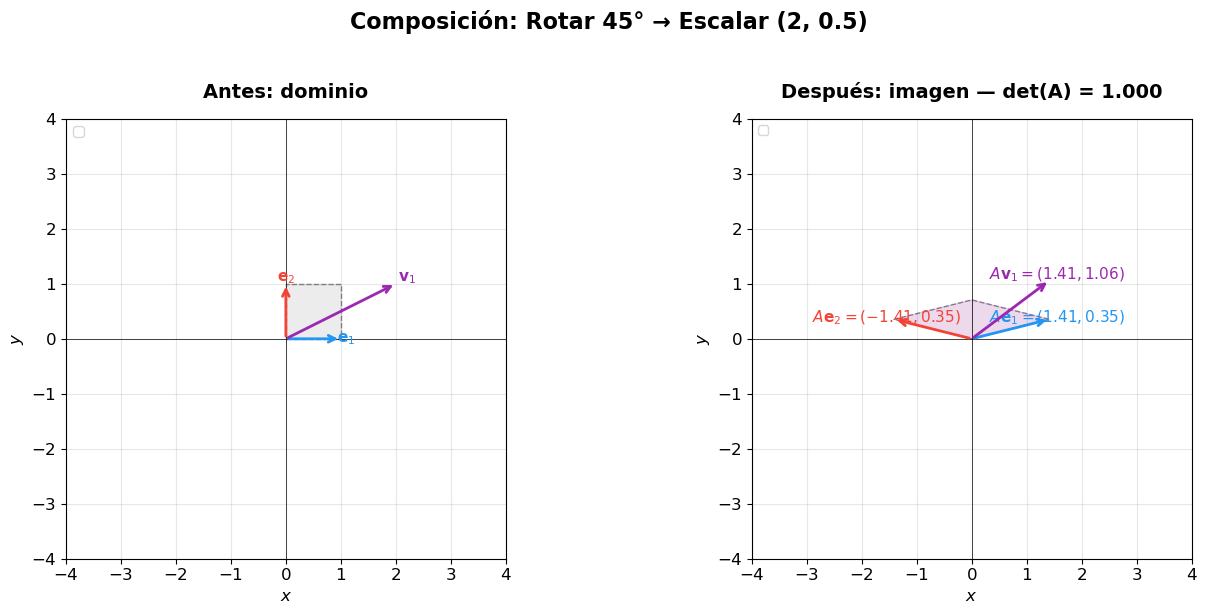

Matriz A:
[[ 1.41421356 -1.41421356]
 [ 0.35355339  0.35355339]]

Determinante: 1.000000
  → Preserva la orientación
  → El área se preserva por |det| = 1.000000


In [18]:
# Composición: primero rotar 45°, luego escalar (2, 0.5)
compuesta_1 = D_aniso @ R45  # Escalar después de rotar
dibujar_transformacion(compuesta_1, 'Composición: Rotar 45° → Escalar (2, 0.5)', vectores_base=[v1])

C:\Users\Eduardo Araque\AppData\Local\Temp\ipykernel_6972\1082664087.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(loc='upper left', fontsize=10)
C:\Users\Eduardo Araque\AppData\Local\Temp\ipykernel_6972\1082664087.py:59: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(loc='upper left', fontsize=9)


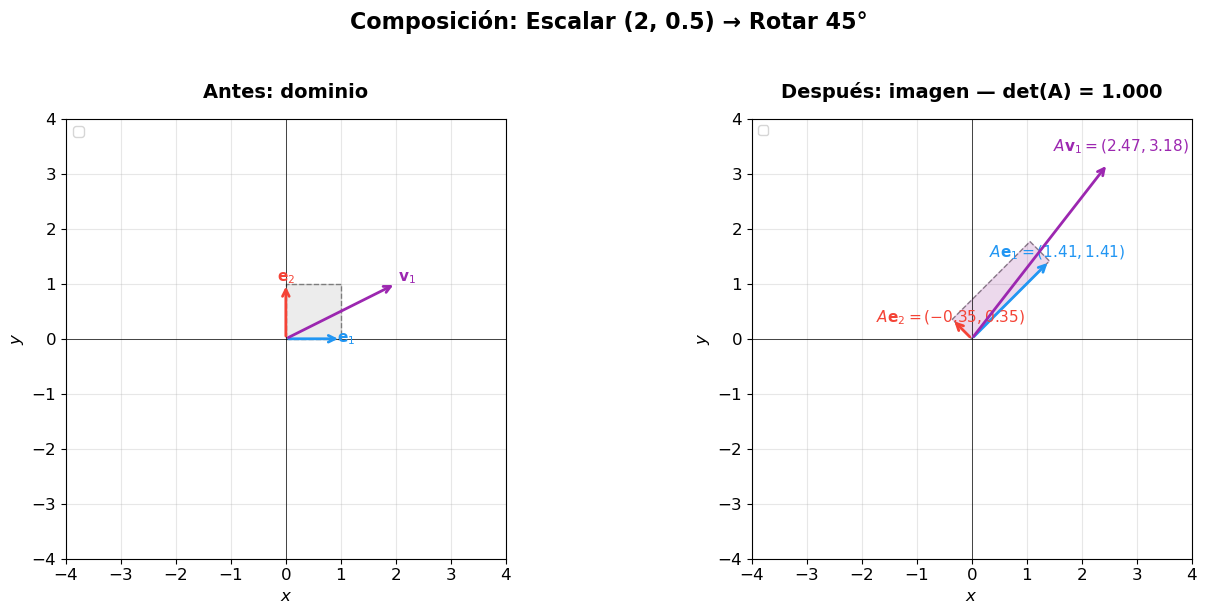

Matriz A:
[[ 1.41421356 -0.35355339]
 [ 1.41421356  0.35355339]]

Determinante: 1.000000
  → Preserva la orientación
  → El área se preserva por |det| = 1.000000


In [19]:
# Composición en orden inverso: primero escalar, luego rotar
compuesta_2 = R45 @ D_aniso  # Rotar después de escalar
dibujar_transformacion(compuesta_2, 'Composición: Escalar (2, 0.5) → Rotar 45°', vectores_base=[v1])

In [20]:
# Verificación: NO son iguales (no conmutatividad)
print(f"D·R =\n{compuesta_1}")
print(f"\nR·D =\n{compuesta_2}")
print(f"\n¿Son iguales? {np.allclose(compuesta_1, compuesta_2)}")
print(f"\nDiferencia máxima entre entradas: {np.max(np.abs(compuesta_1 - compuesta_2)):.6f}")
print("\n→ La multiplicación de matrices NO es conmutativa.")
print("  Esto refleja que rotar y luego escalar ≠ escalar y luego rotar.")

D·R =
[[ 1.41421356 -1.41421356]
 [ 0.35355339  0.35355339]]

R·D =
[[ 1.41421356 -0.35355339]
 [ 1.41421356  0.35355339]]

¿Son iguales? False

Diferencia máxima entre entradas: 1.060660

→ La multiplicación de matrices NO es conmutativa.
  Esto refleja que rotar y luego escalar ≠ escalar y luego rotar.


---
## 7. Resumen visual: todas las transformaciones

Comparación lado a lado del efecto de cada transformación sobre el cuadrado unitario.

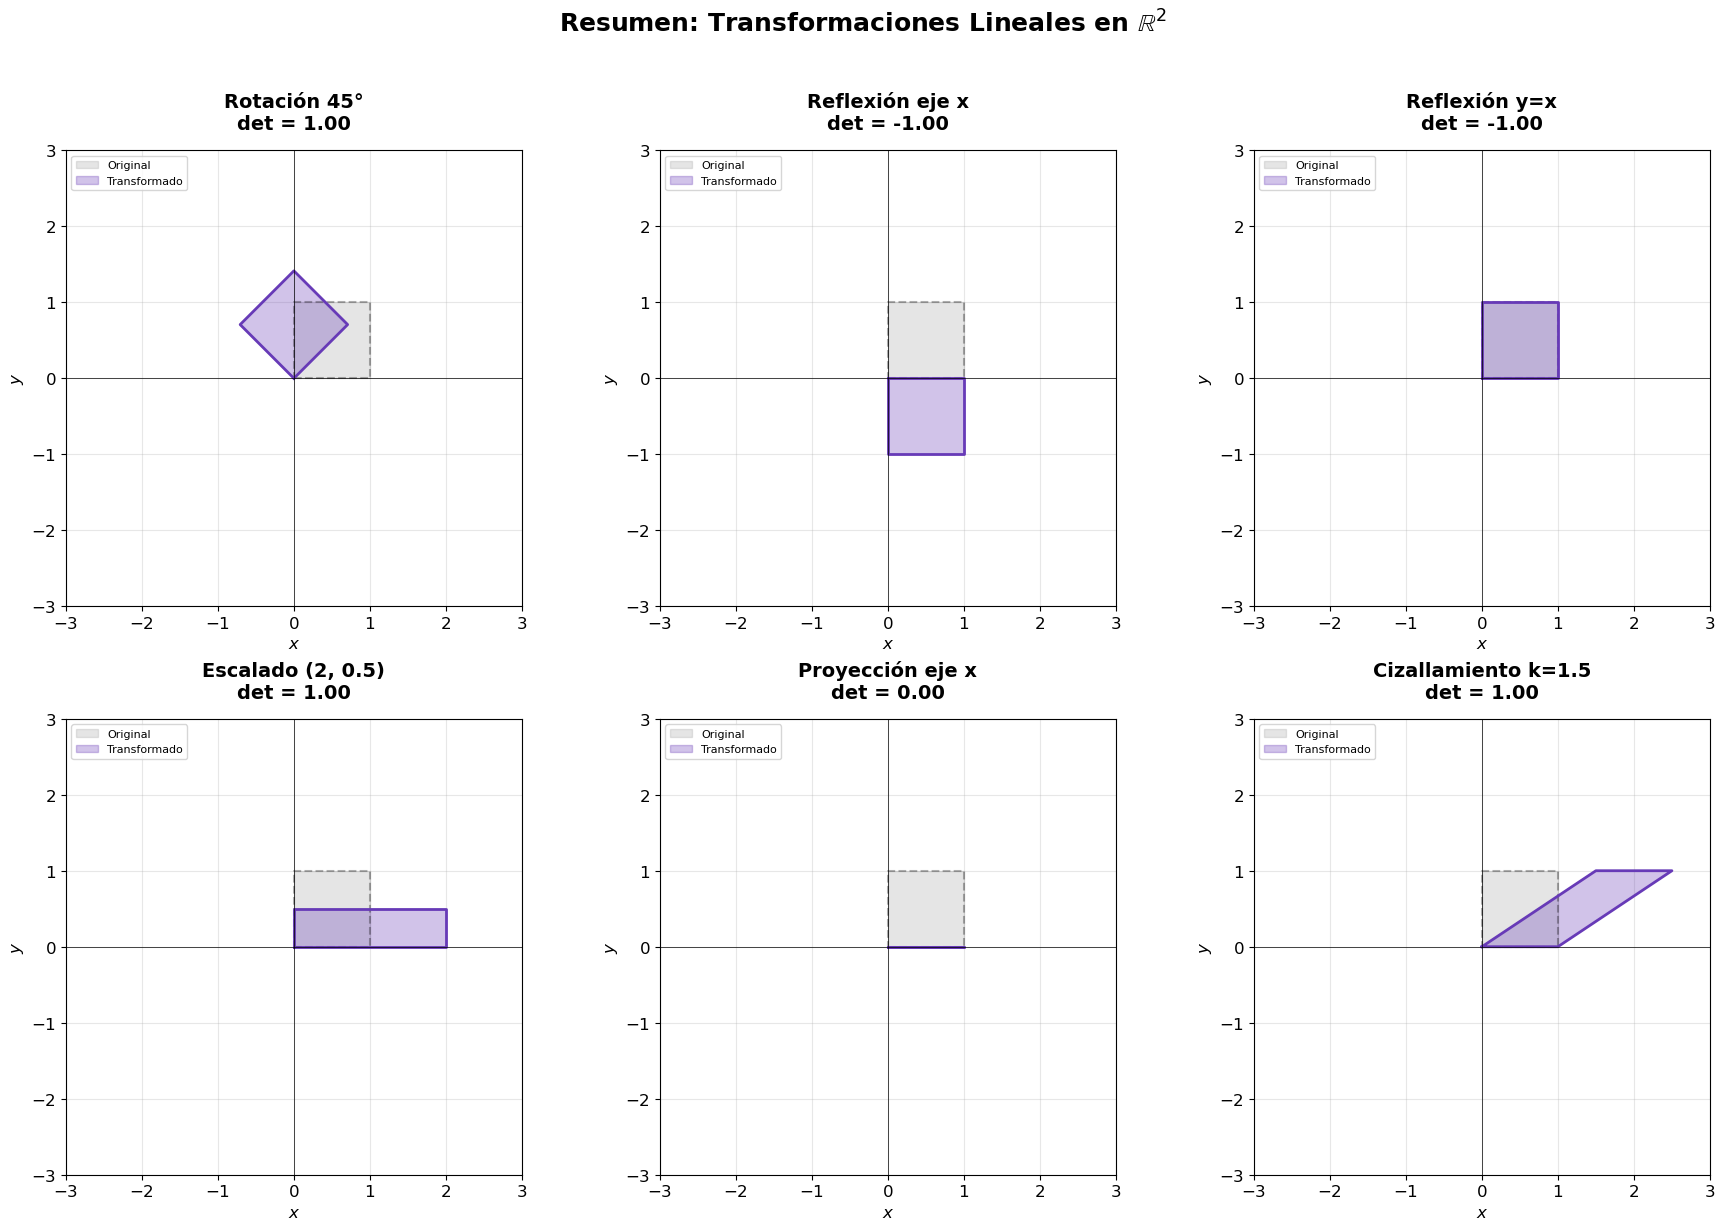

In [21]:
# Panel comparativo de todas las transformaciones
transformaciones = {
    'Rotación 45°': R45,
    'Reflexión eje x': S_eje_x,
    'Reflexión y=x': S_yx,
    'Escalado (2, 0.5)': D_aniso,
    'Proyección eje x': P_x,
    'Cizallamiento k=1.5': H
}

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# Cuadrado unitario original
cuadrado = np.array([[0,0], [1,0], [1,1], [0,1], [0,0]]).T

for ax, (nombre, A) in zip(axes, transformaciones.items()):
    # Cuadrado original
    ax.fill(cuadrado[0], cuadrado[1], alpha=0.2, color='gray', label='Original')
    ax.plot(cuadrado[0], cuadrado[1], 'k--', alpha=0.3)
    
    # Cuadrado transformado
    transformado = A @ cuadrado
    ax.fill(transformado[0], transformado[1], alpha=0.3, color='#673AB7', label='Transformado')
    ax.plot(transformado[0], transformado[1], color='#673AB7', linewidth=2)
    
    det = np.linalg.det(A)
    configurar_ejes(ax, f'{nombre}\ndet = {det:.2f}', lim=3)
    ax.legend(loc='upper left', fontsize=8)

plt.suptitle('Resumen: Transformaciones Lineales en $\mathbb{R}^2$',
             fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/resumen_transformaciones.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. El determinante como factor de cambio de área

El **valor absoluto del determinante** $|\det(A)|$ mide exactamente cuánto cambia el área
de cualquier región al aplicar la transformación $A$. El **signo** indica si se preserva
($\det > 0$) o se invierte ($\det < 0$) la orientación.

| Caso | Significado |
|---|---|
| $|\det(A)| = 1$ | Preserva áreas (rotaciones, reflexiones) |
| $|\det(A)| > 1$ | Expande áreas |
| $0 < |\det(A)| < 1$ | Contrae áreas |
| $\det(A) = 0$ | Colapsa a una dimensión menor (proyecciones) |

In [22]:
# Tabla resumen de determinantes
print(f"{'Transformación':<30} {'det(A)':>10} {'|det(A)|':>10} {'Efecto en área':<25} {'Orientación':<15}")
print('─' * 95)

for nombre, A in transformaciones.items():
    det = np.linalg.det(A)
    abs_det = abs(det)
    
    if abs_det == 0:
        efecto = 'Colapsa a dim. menor'
    elif np.isclose(abs_det, 1):
        efecto = 'Preserva áreas'
    elif abs_det > 1:
        efecto = f'Expande ×{abs_det:.2f}'
    else:
        efecto = f'Contrae ×{abs_det:.2f}'
    
    orient = 'Preserva' if det > 0 else ('Invierte' if det < 0 else 'N/A')
    
    print(f"{nombre:<30} {det:>10.3f} {abs_det:>10.3f} {efecto:<25} {orient:<15}")

Transformación                     det(A)   |det(A)| Efecto en área            Orientación    
───────────────────────────────────────────────────────────────────────────────────────────────
Rotación 45°                        1.000      1.000 Preserva áreas            Preserva       
Reflexión eje x                    -1.000      1.000 Preserva áreas            Invierte       
Reflexión y=x                      -1.000      1.000 Preserva áreas            Invierte       
Escalado (2, 0.5)                   1.000      1.000 Preserva áreas            Preserva       
Proyección eje x                    0.000      0.000 Colapsa a dim. menor      N/A            
Cizallamiento k=1.5                 1.000      1.000 Preserva áreas            Preserva       


---
## Conclusiones a las que llegamos en este notebook

1. **Toda transformación lineal en $\mathbb{R}^2$ es una multiplicación matricial**,  el teorema de representación no es solo teórico; es la base de toda la computación.

2. **El determinante tiene significado geométrico concreto:** mide el cambio de área y la inversión de orientación. No es un número arbitrario.

3. **La composición de transformaciones no es conmutativa:** el orden importa,  rotar y luego escalar produce un resultado diferente que escalar y luego rotar.

4. **Las propiedades algebraicas (ortogonalidad, idempotencia, involución) se verifican numéricamente** con errores del orden de $10^{-16}$,  la aritmética de punto flotante es precisa pero no exacta.

---

**Siguiente notebook:** `02_valores_propios.ipynb` — Valores y vectores propios: las direcciones invariantes de una transformación.